In [ ]:
from fastai.vision.all import *

path = untar_data(URLs.MNIST_SAMPLE)
(path/'train').ls()
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
im3_path = threes[1]
im3 = Image.open(im3_path)
t_im3_s = [ 
    tensor(Image.open(im_3), dtype=torch.float32) for im_3 in threes
]
t_im7_s = [ 
    tensor(Image.open(im_7), dtype=torch.float32) for im_7 in sevens
]
stacked_three = torch.stack(t_im3_s)
stacked_seven = torch.stack(t_im7_s)
# mean_three = stacked_three.mean(0)
# mean_seven = stacked_seven.mean(0)

# any_7 = t_im7_s[10]
# l1_norm_7 = (mean_seven - any_7).abs().mean()
# l1_norm_3 = (mean_three - any_7).abs().mean()

# mse_7 = ((mean_seven - any_7)**2).mean().sqrt()
# mse_3 = ((mean_three - any_7)**2).mean().sqrt()

# if l1_norm_7 < l1_norm_3: 
#     print("It is a seven") 
# else:
#     print("It is a three")

# if mse_7 < mse_3:
#     print("It is a seven") 
# else:
#     print("It is a three")

stacked_three.view(-1, 28*28).shape
train_x = torch.cat([stacked_three, stacked_seven]).view(-1,28*28)
train_y = torch.tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
x = [1,2,3]
y = [2,3,4]
# list(zip(train_x,train_y))[0]
    

RuntimeError: shape '[0, 3]' is invalid for input of size 6

In [38]:
#broadcasting

t1 = tensor([
     [1,2,3],
     [4,5,6]
 ])
 t2 = tensor([
     [1,2,3],
     [4,5,6]
 ])

t = torch.stack([t1,t2])
d = tensor(
    [
        [1,1,1],
        [2,2,2]
    ]
)

t - d

tensor([[[0, 1, 2],
         [2, 3, 4]],

        [[0, 1, 2],
         [2, 3, 4]]])

In [45]:
def mnist_distance(a, b):
    return (a - b).abs().mean((-1,-2))

def is_7(c, mean3, mean7):
    return mnist_distance(c,mean7) < mnist_distance(c, mean3)

valid_threes = (path/'valid'/'3').ls().sorted()
valid_sevens = (path/'valid'/'7').ls().sorted()

stacked_valid_7 = torch.stack(
    [
        tensor(Image.open(im_7), dtype=torch.float32) for im_7 in valid_sevens
    ]
)

stacked_valid_3 = torch.stack(
    [
        tensor(Image.open(im_3), dtype=torch.float32) for im_3 in valid_threes
    ]
)

mnist_distance(stacked_valid_7, mean_seven)

accuracy_7 = is_7(stacked_valid_7, mean_three, mean_seven).float().mean()
accuracy_7

tensor(0.9854)

63251.17578125
12533.0888671875
2935.669189453125
1119.5350341796875
775.8583984375
710.8157958984375
698.4992065429688
696.1600341796875
695.7088012695312
695.6148681640625


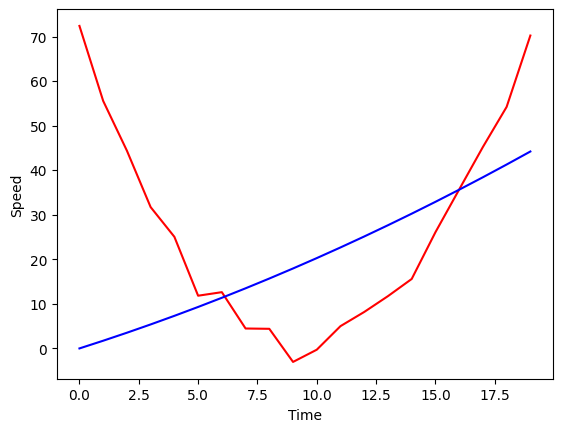

In [62]:
#optimising a model using stochastic gradient descent
from fastai.vision.all import *

time = torch.arange(0,20).float() #why torch.arange and not numpy.arange?
time
speed = torch.randn(20)*3 + 0.75*(time - 9.5)**2 + 1
speed

def f(t, params):
    a, b, c = params
    return a*(t**2) + (b*t) + c

def mse(preds, targets):
    return ((preds - targets)**2).mean()

#step 1
params = torch.randn(3).requires_grad_()
# print(f"params 1: {params}")
# #step 2
# preds = f(time, params)
# #step 3
# loss = mse(preds, speed)
# print(f"loss 1: {loss}")
# #step 4
# loss.backward()
# params.grad
# #step 5
# lr = 1e-5
# params =- params.grad*lr
# print(f"params 2: {params}")
# params.grad = None

# preds = f(time, params)
# loss = mse(preds, speed)
# print(f"loss 2: {loss}")

def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    lr = 1e-5
    params.data -= lr*params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds
    
for i in range(10): apply_step(params) 
params
# print(f(time,params))
# print(speed)
final_preds = f(time, params)
plt.plot(time.tolist(), speed.tolist(), 'r-')
plt.plot(time.tolist(), final_preds.tolist(), 'b-')
plt.xlabel('Time')
plt.ylabel('Speed')
plt.show()

intial params: tensor([ 1.2627, -0.2398,  0.1841, -0.5571, -0.0584, -0.4673,  0.7001, -0.4401,
        -0.0068], requires_grad=True)
final params: tensor([ 1.1802e+00,  1.7219e-02,  1.0735e-01, -5.6363e-01,  1.3899e-04,
        -6.0882e-02,  4.8887e-01,  1.7046e-01, -1.1672e-02],
       requires_grad=True)


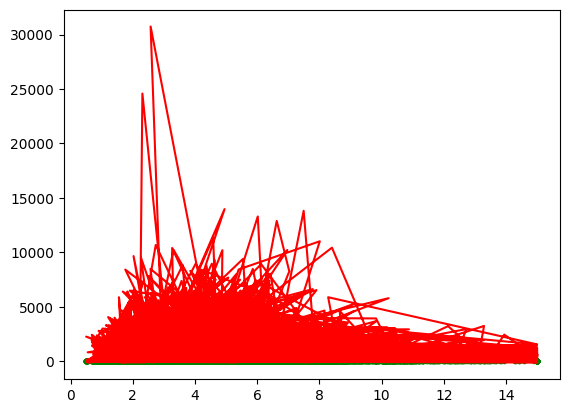

In [118]:
#california housing

from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
california = fetch_california_housing()
X = california.data  # Features (8 columns)
y = california.target  # Target (median house value)

# Convert to DataFrame for easier inspection (optional)
df = pd.DataFrame(X, columns=california.feature_names)
df['target'] = y

med_inc = tensor(df['MedInc'],dtype=torch.float32)
house_age = tensor(df['HouseAge'],dtype=torch.float32)
ave_rooms = tensor(df['AveRooms'],dtype=torch.float32)
ave_bed_rooms = tensor(df['AveBedrms'],dtype=torch.float32)
population = tensor(df['Population'],dtype=torch.float32)
ave_occup = tensor(df['AveOccup'],dtype=torch.float32)
latitude = tensor(df['Latitude'],dtype=torch.float32)
logitude = tensor(df['Longitude'],dtype=torch.float32)
target = tensor(df['target'],dtype=torch.float32)

def f(params, med_inc, house_age, ave_rooms, ave_bed_rooms, population, ave_occup, latitude, longitude):
    a, b, c, d, e, f, g, h, i = params
    return ( 
        a*med_inc + b*house_age + c*ave_rooms + d*ave_bed_rooms + e*population + f*ave_occup + g*latitude + h*longitude + i
    )

def mse(preds, target):
    return ((preds - target)**2).mean()

plt.plot(med_inc.tolist(), target.tolist(), 'g.')
len(med_inc)

params = torch.randn(9).requires_grad_()
print(f"intial params: {params}")

# preds = f(params, med_inc, house_age, ave_rooms, ave_bed_rooms, population, ave_occup, latitude, logitude)

# loss = mse(preds, target)

# loss.backward()
# print(f"loss 1: {loss}")
# grad = params.grad.data
# lr = 0.0000001

# params.data -= grad*lr
# params.grad = None

# preds = f(params, med_inc, house_age, ave_rooms, ave_bed_rooms, population, ave_occup, latitude, logitude)
# loss = mse(preds, target)
# print(f"loss 2: {loss}")
lr = 0.0000001
count = 0
limit = 1000
def step(params, prn=True):
    preds = f(params, med_inc, house_age, ave_rooms, ave_bed_rooms, population, ave_occup, latitude, logitude)
    loss = mse(preds, target)
    loss.backward()
    params.data -= lr*params.grad.data
    params.grad = None
    #if prn: print(loss.item())
    return preds
    
for i in range(100000): step(params)

# def apply_step(params, prn=True):
#     preds = f(params, med_inc)
#     loss = mse(preds, target)
#     loss.backward()
#     lr = 0.0001
#     params.data -= lr*params.grad.data
#     params.grad = None
#     #if prn: print(loss.item())
#     return preds
    
# for i in range(1000): apply_step(params) 

# len(preds), len(med_inc)
plt.plot(med_inc.tolist(),preds.tolist(),'r-')
print(f"final params: {params}")

In [141]:
a = tensor([
    [1.0, 2.0, 3.0],
    [0.5, 0.6, 0.7]
])
b = tensor([
    [1.0, 2.0, 3.0],
    [0.5, 0.6, 0.7]
]) 

c = torch.stack([a,b])
c.view(-1, 3)
a.shape
x = a.view(-1, 6)
x.shape
x
c, c.view(-1, 6)

stacked_three

NameError: name 'stacked_three' is not defined

In [10]:
from fastai.vision.all import *

train_x = tensor(
    [
        [0.0, 1.0, 2.0],
        [3.0, 4.0, 5.0],
        [6.0, 7.0, 8.0]
    ]
)
weights = torch.tensor(([2.0, 3.0, 4.0])).view(3,-1)
weights
train_x, weights, train_x@weights

(tensor([[0., 1., 2.],
         [3., 4., 5.],
         [6., 7., 8.]]),
 tensor([[2.],
         [3.],
         [4.]]),
 tensor([[11.],
         [38.],
         [65.]]))